# LLM-Powered Topic Classification and Evaluation

This notebook demonstrates how to use a Large Language Model (LLM) for topic classification on a dataset. It includes steps for setting up the environment, defining labels, performing classification in batches, and evaluating the results using confusion matrices.

## Table of Contents

1.  [Setup and Configuration](#setup-and-configuration)
    *   [Imports](#imports)
    *   [Global Variables](#global-variables)
    *   [LLM Client Configuration](#llm-client-configuration)
    *   [LLM Helper Function](#llm-helper-function)
2.  [Label Definitions](#label-definitions)
    *   [Label Descriptions](#label-descriptions)
    *   [Shuffled Labels for Prompt](#shuffled-labels-for-prompt)
    *   [Old and New Labels](#old-and-new-labels)
    *   [Get Shuffled Labels Function](#get-shuffled-labels-function)
3.  [Classification Logic](#classification-logic)
    *   [Core Classification Function (`classify_batch`)](#core-classification-function-classify_batch)
    *   [Results Management (Load/Save)](#results-management-load-save)
    *   [Validate Prediction Function](#validate-prediction-function)
4.  [Data Loading and Preparation](#data-loading-and-preparation)
    *   [Load Dataset from Hugging Face](#load-dataset-from-hugging-face)
    *   [Manage Shuffled Dataset](#manage-shuffled-dataset)
5.  [Main Classification Workflow](#main-classification-workflow)
6.  [Evaluation and Visualization](#evaluation-and-visualization)
    *   [Plot Confusion Matrix (All Labeled Data)](#plot-confusion-matrix-all-labeled-data)
    *   [Plot Confusion Matrix (Old to New Labels - Percentage)](#plot-confusion-matrix-old-to-new-labels---percentage)
    *   [Plot Confusion Matrix (Old to New Labels - Counts)](#plot-confusion-matrix-old-to-new-labels---counts)
    *   [Misclassification Analysis](#misclassification-analysis)
    *   [Filter Results by Generation Group](#filter-results-by-generation-group)
    *   [Generic Confusion Matrix Plotter](#generic-confusion-matrix-plotter)

## <a name="setup-and-configuration"></a>1. Setup and Configuration

In [ ]:
import os
import json
import time
import random
from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### <a name="imports"></a>Imports

In [ ]:
HF_DATASET = "maryamdar/topic_classification_dataset_gen"

# If your dataset has a specific split:
HF_SPLIT = "train"

DATASET_SHUFFLE_SEED = 42
BATCH_SIZE = 10

START_INDEX = 0
END_INDEX = 9102

REQUESTS_BEFORE_SLEEP = 30
SLEEP_SECONDS = 30

### <a name="global-variables"></a>Global Variables

In [ ]:
# EXCLUDED_GROUPS is no longer used for grouping or file naming,
# so this variable can be left as is or removed if desired.

In [ ]:
client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key="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"
)

MODEL ="nvidia/nemotron-3-ultra-550b-a55b"

### <a name="llm-client-configuration"></a>LLM Client Configuration

In [ ]:
def llm_call(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=1,
        top_p=0.95,
        max_tokens=4096,
        seed=42,
        stream=False,
        extra_body={
        "chat_template_kwargs": {
            "enable_thinking": False
        }
      }
    )

    return response.choices[0].message.content.strip()

## <a name="label-definitions"></a>2. Label Definitions

### <a name="llm-helper-function"></a>LLM Helper Function

In [ ]:
label_descriptions = {
    "Desktop & Mobile & Web Development":"Covers: building software applications for browsers, phones, and desktop computers. Front-end and back-end web development, UI/UX design, responsive design, mobile app development (native and cross-platform), desktop application development, API design and implementation, application-level server-side logic (the code a developer writes), and general programming, algorithms, or data structures questions asked in the context of building an application.\nExcludes: provisioning or administering the servers and cloud resources that host the application (Infrastructure), machine learning or AI model integration (AI / Machine Learning / Data Science), and security vulnerabilities, exploits, or secure-coding audits (Cybersecurity).",
    "Cybersecurity" : "Covers: protecting systems and data from unauthorized access, damage, or disruption, regardless of what kind of system is being protected. Vulnerabilities, exploits, malware analysis, encryption, authentication and access control, network security, incident response, penetration testing, and security auditing of web apps, infrastructure, or AI systems (including AI-specific attacks such as prompt injection or model poisoning).\nExcludes: general IT infrastructure or server management with no security angle (Infrastructure).Note: any question centered on an attack, vulnerability, or defense mechanism belongs here regardless of which domain it targets, including healthcare or financial systems. Domain labels like Healthcare Organizations or Corporate Finance do not carry their own security content; that content routes here.",
    "AI / Machine Learning / Data Science" : "Covers: building, training, and deploying intelligent systems that learn from data. Natural language processing, computer vision, large language models, deep learning, time series analysis, tabular data analysis, statistical modeling for prediction, data pipelines built for ML, MLOps, and model deployment or serving infrastructure specific to an ML model. Robotics perception, planning, and control algorithms (the software/AI side of a robot).\nExcludes: general web or application programming with no ML component (Web & Mobile Development & Desktop), attacks or defenses against ML systems (Cybersecurity), general-purpose cloud or server infrastructure not specific to ML workloads (Infrastructure), and the physical/mechanical hardware of a robot (Mechanical & Electrical Engineering).",
    "Infrastructure (DevOps, Cloud, Databases, Networking)" : "Covers: the backbone systems that keep software running at scale. Cloud platform administration, containers and orchestration, CI/CD pipeline setup, database administration, networking, sysadmin tasks, server provisioning, and general deployment automation not specific to an ML model.\nExcludes: security-specific configuration or attacks (Cybersecurity), ML-specific deployment or serving pipelines (AI / Machine Learning / Data Science), and writing the application's own front-end or back-end logic (Web & Mobile Development & Desktop).",
    "Clinical Diagnosis, Treatment & Surgery" : "Covers: somatic/physical medicine: symptoms, differential diagnosis, surgical procedures, imaging findings, prognosis, non-psychiatric treatment plans, and diet or lifestyle changes prescribed as treatment for a diagnosed physical condition. Centered on the patient's physical condition and clinical course.\nExcludes: psychiatric diagnoses and treatment (Mental Health), drug selection, dosing, or mechanism discussed in isolation from a clinical narrative (Medication & Pharmacology), diet or nutrition with no diagnosed condition involved (Nutrition), and billing or insurance aspects of care (Healthcare Organizations, System, Hospitals).",
    "Medication & Pharmacology" : "Covers: the drug itself, independent of the condition it treats: mechanism of action, pharmacokinetics, drug classes, prescribing guidelines, side effects, drug interactions, and pharmaceutical industry or manufacturing topics.\nExcludes: psychiatric medication discussed as part of a therapy or treatment narrative (Mental Health), and drug pricing, policy, or formulary decisions (Healthcare Organizations, System, Hospitals).",
    "Mental Health" : "Covers: the psychiatric and psychological domain specifically: psychiatric diagnosis (DSM/ICD categories), psychotherapy modalities, counseling process, and psychiatric medication when discussed as part of a treatment or therapy narrative.\nExcludes: a psychiatric drug's pharmacology discussed with no therapeutic or patient narrative (Medication & Pharmacology), and non-psychiatric physical conditions (Clinical Diagnosis, Treatment & Surgery).Note: route by narrative framing, not by drug class. 'How does sertraline work' routes to Medication & Pharmacology. 'Is sertraline helping with my anxiety' routes to Mental Health.",
    "Healthcare Organizations, System, Hospitals" : "Covers: the structural and administrative layer of healthcare: insurance mechanics, hospital operations, billing, health policy, and regulation of the system itself, not of individual patient care.\nExcludes: the clinical or psychiatric content that happens to occur within a hospital (Clinical Diagnosis, Treatment & Surgery or Mental Health), and drug-specific regulation such as FDA drug approval (Medication & Pharmacology).",
    "Nutrition" : "Covers: food and diet as a standalone domain, with no diagnosed disease being treated: nutrients, food science, general meal planning, and weight management achieved through food choices alone.\nExcludes: diet prescribed as treatment for a diagnosed medical condition (Clinical Diagnosis, Treatment & Surgery), and exercise or physical training for weight management or health, even when discussed alongside diet (Fitness).Note: this is the fix for the main overlap flagged in the brief. Nutrition is food and eating only. The moment exercise, workouts, or training enters the conversation, that part of the message routes to Fitness. A message that asks about both should be treated as touching two labels rather than forced into one.",
    "Payments & Personal Budgeting" : "Covers: individual cash flow and personal financial administration: day-to-day spending, bill tracking, budgeting methodology, personal bank accounts and cards, personal loans and mortgages, personal tax filing, and the decision to save for retirement (how much, when to start).\nExcludes: what those retirement or other savings are invested in (Investment, Markets & Cryptocurrency), business accounts or banking activity (Corporate), and legal or regulatory matters (Law).",
    "Investment, Markets & Cryptocurrency" : "Covers: asset growth and markets: stocks, bonds, cryptocurrency, trading, portfolio construction, market analysis, and what retirement or other personal savings are invested in.\nExcludes: the decision to save for retirement itself (Payments & Personal Budgeting), corporate valuation or mergers done for business strategy rather than public market trading (Corporate), and legal or regulatory matters (Law).",
    "Corporate" : "Covers: business-entity finance: bookkeeping, corporate financial strategy, audits, business tax, and business banking.\nExcludes: the personal finances of a business owner (Payments & Personal Budgeting), legal or regulatory matters (Law), and public market trading of corporate stock (Investment, Markets & Cryptocurrency).",
    "Physics, Mathematics" : "Covers: fundamental laws of nature and abstract structures: physical laws, mechanics, quantum physics, astrophysics, mathematical theory, statistics theory, applied mathematics, and mathematical modeling that is not tied to a specific chemical or biological system.\nExcludes: chemical reactions and compounds (Chemistry), living organisms and biological processes (Biology), and applied engineering design (Engineering).",
    "Chemistry" : "Covers: the study of matter and its transformations: chemical reactions, compounds, organic and inorganic chemistry, biochemistry (the chemical mechanisms operating inside living things), materials science, and chemical analysis.\nExcludes: physical laws and pure mathematics (Physics, Mathematics), the organism-level biological processes those chemical mechanisms support, such as genetics, whole-body physiology, or ecology (Biology), and medical diagnosis or treatment applications (Medical).",
    "Biology" : "Covers: living systems at the organism, population, and ecosystem level: genetics, ecology, physiology as a system, evolution, microbiology, zoology, botany, and marine biology.\nExcludes: the underlying chemical reaction mechanisms (Chemistry), physical laws and mathematics (Physics, Mathematics), and medical diagnosis or treatment applications (Medical).Note: 'how does metabolism work chemically' routes to Chemistry. 'Why do animals in cold climates evolve faster metabolisms' routes to Biology.",
    "Team Sports" : "Covers: collective athletic competition: football, basketball, soccer, hockey, baseball, volleyball, and similar team sports, including players, leagues, matches, game strategy, team-specific practice and skill drills, and coaching.\nExcludes: solo athletic pursuits (Individual Sports), general fitness or conditioning training not tied to a specific sport (Fitness), and injuries or medical treatment (Medical).",
    "Individual Sports" : "Covers: solo athletic pursuits: tennis, golf, boxing, track and field, swimming, cycling, martial arts, including techniques, competitions, and sport-specific training methods.\nExcludes: team-based competition (Team Sports), general fitness training not tied to a specific sport (Fitness), and injuries or medical treatment (Medical).",
    "Fitness" : "Covers: exercise and physical training for general health and performance, not tied to a specific competitive sport: workouts, gym training, strength training, cardio, flexibility, exercise science, and workout programming.\nExcludes: competitive sport-specific technique or strategy (Team Sports or Individual Sports), food or diet as a topic (Nutrition), and medical conditions or injuries (Medical).",
    "Civil, Structural & Architecture" : "Covers: designing and building the physical, non-machine world: infrastructure, bridges, structural design, building design, urban planning, construction, construction materials, geotechnical engineering, and architecture.\nExcludes: machines, manufacturing, and robotics hardware (Mechanical & Electrical Engineering), and software (Programming / Technology).",
    "Mechanical & Electrical Engineering" : "Covers: machines, energy, and automation: manufacturing, the physical hardware of robotics, circuits, power systems, electronics, automation, control system hardware, thermodynamics, and electrical design.\nExcludes: civil infrastructure and building design (Civil, Structural & Architecture), and the software or AI running on the machine, such as robotics perception or planning algorithms (AI / Machine Learning / Data Science).",
    "Family & Relationships" : "Covers: interpersonal connections and dynamics: romantic relationships, friendships, family dynamics, parenting, dating, marriage, divorce, custody, and adoption, focused on the emotional or relational content.\nExcludes: self-focused growth with no other specific person centrally involved (Personal), the logistics of a trip even if taken with a partner or family (Travel), and the legal procedure of divorce, custody, or adoption (Law: Family).",
    "Personal" : "Covers: self-focused growth and daily life: self-improvement, life goals, mindfulness, personal values, hobbies, appearance, lifestyle, and daily routines, where no other person's relationship to the user is the central topic.\nExcludes: relationship dynamics with another specific person (Family & Relationships), and travel planning or logistics (Travel).",
    "Travel" : "Covers: planning and experiencing movement through the world: trip planning, destinations, vacations, leisure transportation, travel logistics, accommodation, activities, and cultural experiences.\nExcludes: the relationship dynamics of who the user is traveling with (Family & Relationships), and general self-improvement (Personal).",
    "Marketing & Sales" : "Covers: attracting and converting customers at any company stage: advertising, branding, sales strategy, digital marketing, content marketing, lead generation, and conversion optimization.\nExcludes: the decision to start a business or raise funding (Entrepreneurship & Startups), and internal operations or HR (Management & Strategy & Human Resources).",
    "Entrepreneurship & Startups" : "Covers: building new ventures: business planning, fundraising and venture capital, founder-specific topics, startup culture, early-stage growth strategy, and pitch decks.\nExcludes: ongoing customer acquisition tactics, which apply regardless of company stage (Marketing & Sales), and managing an already-established company's operations (Management & Strategy & Human Resources).",
    "Management & Strategy & Human Resources" : "Covers: running and organizing an established business: leadership, corporate strategy, human resources, hiring, operations, organizational structure, and employee management.\nExcludes: customer-facing marketing and sales tactics (Marketing & Sales), and the early-stage founding or funding of a company (Entrepreneurship & Startups).",
    "Criminal Law" : "Covers: government prosecution of offenses against the state: charges, defenses, sentencing, appeals, criminal procedure, evidence rules, law enforcement, and criminal domestic violence.\nExcludes: non-criminal family matters (Family), business regulation (Corporate), and private civil disputes (Civil).",
    "Family Law" : "Covers: legal aspects of family relationships: marriage, divorce, custody, adoption, child support, alimony, and domestic relations procedure.\nExcludes: criminal domestic violence charges (Criminal), business matters (Corporate), private civil disputes unrelated to family (Civil), and the emotional or relational, non-legal side of these topics (Personal: Family & Relationships).",
    "Corporate Law" : "Covers: law governing business entities: corporate governance, shareholders, directors, incorporation, securities law, mergers, and business regulation.\nExcludes: criminal fraud prosecution (Criminal), family matters (Family), and private civil disputes (Civil).",
    "Civil Law" : "Covers: private legal disputes between individuals or entities: personal injury, negligence, property disputes, contracts, consumer disputes, debt disputes, defamation, and landlord-tenant disputes.\nExcludes: criminal prosecution (Criminal), family matters (Family), and corporate regulation (Corporate).",
    "Game" : "Covers: interactive entertainment and play: video and tabletop games, game design, the game industry, reviews, gaming culture, esports, game mechanics, and narrative writing created specifically for games.\nExcludes: film, music, non-game literature, and visual art (Film, Music, Literature, Painting).",
    "Film" : "Covers: moving images as art and storytelling: filmmaking, film analysis, actors and directors, genres, film history, cinema, and screenwriting.\nExcludes: gaming (Game), music (Music), non-film literature (Literature), and visual art (Painting).",
    "Music" : "Covers: organized sound as art and expression: music theory, artists, production, genres, music industry, performance, and composition.\nExcludes: gaming, film, literature, and visual art (Game, Film, Literature, Painting).",
    "Literature" : "Covers: written and spoken word as art, outside of game- or film-specific writing: books, standalone poetry, authors, literary analysis, publishing, and creative writing.\nExcludes: game narrative writing (Game), screenwriting (Film), music (Music), and visual art (Painting).",
    "Painting" : "Covers: visual creation and representation: painting, drawing, sculpture, photography, art techniques, art history, visual design, and illustration.\nExcludes: gaming, film, music, and literature (Game, Film, Music, Literature)."
}

### <a name="label-descriptions"></a>Label Descriptions

In [ ]:
import random

shuffled_labels = list(label_descriptions.keys())
random.shuffle(shuffled_labels)

label_list_desc = "\n\n".join(
    f"LABEL: {label}\n"
    f"DESCRIPTION: {label_descriptions[label]}"
    for label in shuffled_labels
)

### <a name="shuffled-labels-for-prompt"></a>Shuffled Labels for Prompt

In [ ]:
print(label_list_desc)

LABEL: Biology
DESCRIPTION: Covers: living systems at the organism, population, and ecosystem level: genetics, ecology, physiology as a system, evolution, microbiology, zoology, botany, and marine biology.
Excludes: the underlying chemical reaction mechanisms (Chemistry), physical laws and mathematics (Physics, Mathematics), and medical diagnosis or treatment applications (Medical).Note: 'how does metabolism work chemically' routes to Chemistry. 'Why do animals in cold climates evolve faster metabolisms' routes to Biology.

LABEL: Travel
DESCRIPTION: Covers: planning and experiencing movement through the world: trip planning, destinations, vacations, leisure transportation, travel logistics, accommodation, activities, and cultural experiences.
Excludes: the relationship dynamics of who the user is traveling with (Family & Relationships), and general self-improvement (Personal).

LABEL: Team Sports
DESCRIPTION: Covers: collective athletic competition: football, basketball, soccer, hocke

In [ ]:
# ============================================================
# CLASSIFY BATCH
# ============================================================

def classify_batch(
    texts,
    shuffled_labels,
    retry_sleep=5,
):

    # label_list = "\n".join(
    #     f"- {label}"
    #     for label in shuffled_labels
    #   )
    text_list = "\n\n".join(
      f"TEXT {i + 1}:\n{text}"
      for i, text in enumerate(texts)
      )



    prompt = f"""
    You are a text classification system.

    Your task is to classify every text into EXACTLY ONE of the provided labels.

    Use the label descriptions as the semantic definitions of the categories.
    Choose the label whose description BEST matches the primary topic and intent of the text.

    The ONLY valid labels are the labels listed below.

    {label_list_desc}

    IMPORTANT LABELING RULES:

    - Classify every text into exactly ONE label.
    - Use the descriptions to determine the most appropriate label.
    - Focus on the PRIMARY topic of the text.
    - When multiple labels seem relevant, choose the ONE that best represents the main intent of the text.
    - Prefer the most specific applicable label over a broad or general label.
    - Do not choose a label merely because one word in the text matches it.
    - Consider the meaning and context of the entire text.
    - The descriptions are guidance for classification; they must NOT appear in the predictions.
    - Predictions must contain ONLY the exact label names.
    - Never return numbers.
    - Never return label indexes.
    - Never return label positions.
    - Never return "1", "2", "3", etc.
    - Never shorten a label.
    - Never modify a label.
    - Never create a new label.
    - Never combine multiple labels.
    - Never return more than one label for a text.

    OUTPUT RULES:

    - Classify every text.
    - Return exactly one prediction for every text.
    - The number of predictions MUST equal the number of texts.
    - Use ONLY the exact labels provided above.
    - Keep the prediction order exactly the same as the input text order.
    - Do NOT include explanations.
    - Do NOT include reasoning.
    - Do NOT include confidence scores.
    - Do NOT include the descriptions.
    - Return ONLY valid JSON.
    - Do not use markdown code fences.

    Required JSON format:

    {{
        "predictions": [
            "exact label for TEXT 1",
            "exact label for TEXT 2",
            "exact label for TEXT 3"
        ]
    }}

    Texts to classify:

    {text_list}
    """


    attempt = 0

    # ========================================================
    # KEEP TRYING UNTIL VALID RESULT
    # ========================================================

    while True:

        attempt += 1

        print(
            f"\nLLM request attempt {attempt}..."
        )

        try:

            # ------------------------------------------------
            # CALL LLM
            # ------------------------------------------------
            content = llm_call(prompt)
            # print(content)

            if content is None:

                raise ValueError(
                    "LLM returned None"
                )

            content = content.strip()

            if not content:

                raise ValueError(
                    "LLM returned an empty response"
                )

            # ------------------------------------------------
            # PARSE JSON
            # ------------------------------------------------

            try:

                parsed = json.loads(
                    content
                )

            except json.JSONDecodeError as e:

                raise ValueError(
                    f"Invalid JSON: {e}"
                )

            # ------------------------------------------------
            # GET PREDICTIONS
            # ------------------------------------------------

            predictions = parsed.get(
                "predictions"
            )

            if not isinstance(
                predictions,
                list,
            ):

                raise ValueError(
                    "'predictions' is not a list"
                )

            # ------------------------------------------------
            # VALIDATE COUNT
            # ------------------------------------------------

            if len(predictions) != len(texts):
                print(parsed)
                raise ValueError(
                    f"Expected "
                    f"{len(texts)} predictions, "
                    f"got {len(predictions)}"
                )

            # ------------------------------------------------
            # VALIDATE EVERY PREDICTION
            # ------------------------------------------------

            validated_predictions = []

            for prediction in predictions:

                validated = validate_prediction(
                    prediction,
                    labels,
                )

                # IMPORTANT:
                # If validation returns None,
                # the whole batch is invalid.

                if validated is None:

                    raise ValueError(
                        f"Invalid prediction: "
                        f"{prediction}"
                    )

                validated_predictions.append(
                    validated
                )

            # ------------------------------------------------
            # EXTRA SAFETY CHECK
            # ------------------------------------------------

            if len(validated_predictions) != len(texts):

                raise ValueError(
                    "Validation changed prediction count"
                )

            if any(
                prediction is None
                for prediction
                in validated_predictions
            ):

                raise ValueError(
                    "At least one prediction is None"
                )

            # =================================================
            # SUCCESS
            # =================================================

            print(
                f"Valid response received "
                f"on attempt {attempt}."
            )

            return validated_predictions

        # ====================================================
        # ANY ERROR -> RETRY
        # ====================================================

        except Exception as e:

            print(
                f"\nWARNING: Classification attempt "
                f"{attempt} failed."
            )

            print(
                f"Reason: {e}"
            )

            print(
                f"Retrying in {retry_sleep} seconds..."
            )

            time.sleep(
                retry_sleep
            )

### <a name="core-classification-function-classify_batch"></a>Core Classification Function (`classify_batch`)

## <a name="classification-logic"></a>3. Classification Logic

In [ ]:
RESULTS_DIR = "llm_classification_results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True,
)

# ============================================================
# OUTPUT FILE NAMES
# ============================================================

# Since EXCLUDED_GROUPS is not being used for filtering or naming,
# we can directly set the suffix.
excluded_suffix = "excluded_none"


SHUFFLED_DATA_FILE = os.path.join(
    RESULTS_DIR,
    f"shuffled_dataset_{excluded_suffix}.json",
)

RESULTS_FILE = os.path.join(
    RESULTS_DIR,
    f"classification_results_{excluded_suffix}.json",
)


### <a name="results-management-load-save"></a>Results Management (Load/Save)

In [ ]:
# labels = [

#     # Technology
#     "Desktop Development",
#     "Mobile Development",
#     "Web Development",

#     "Cybersecurity",

#     "Artificial Intelligence",
#     "Machine Learning",
#     "Data Science",

#     "DevOps",
#     "Cloud Computing",
#     "Databases",
#     "Computer Networking",

#     # Healthcare
#     "Clinical Diagnosis",
#     "Medical Treatment",
#     "Surgery",

#     "Medication & Pharmacology",

#     "Mental Health (Clinical)",

#     "Healthcare Organizations & Systems",
#     "Hospitals",

#     "Nutrition",

#     # Finance
#     "Payments",
#     "Personal Budgeting",

#     "Banking",

#     "Investment & Markets",
#     "Cryptocurrency",

#     "Corporate Accounting",

#     # Science
#     "Physics",
#     "Mathematics",

#     "Chemistry",

#     "Biology",

#     # Sports
#     "Team Sports",
#     "Individual Sports",

#     "Fitness & Training",

#     # Engineering
#     "Civil Engineering",
#     "Structural Engineering",
#     "Architecture",

#     "Mechanical Engineering",
#     "Electrical Engineering",

#     # Personal / Social
#     "Family & Relationships",

#     "Personal Growth & Reflection",

#     "Travel",

#     # Business
#     "Marketing",
#     "Sales",

#     "Entrepreneurship & Startups",

#     "Management",
#     "Business Strategy",
#     "Human Resources",

#     # Law
#     "Criminal Law",
#     "Civil Law",

#     "Labor Law",
#     "Family Law",
#     "Contract Law",

#     "Corporate Law",
#     "Regulatory Law",
#     "International Law",

#     "General Law (misc.)",

#     # Arts & Entertainment
#     "Games",
#     "Film",
#     "Music",
#     "Literature",
#     "Painting",
# ]

In [ ]:
old_labels = [

    "Desktop & Mobile & Web Development",

    "Cybersecurity",

    "AI / Machine Learning / Data Science",

    "Infrastructure (DevOps, Cloud, Databases, Networking)",

    "Clinical Diagnosis, Treatment & Surgery",

    "Medication & Pharmacology",

    "Mental Health (Clinical)",

    "Healthcare Organizations, System, Hospitals",

    "Nutrition",

    "Payments & Personal Budgeting",

    "Banking",

    "Investment, Markets & Cryptocurrency",

    "Corporate Accounting",

    "Physics & Mathematics",

    "Chemistry",

    "Biology",

    "Team Sports",

    "Individual Sports",

    "Fitness & Training",

    "Civil, Structural & Architecture",

    "Mechanical & Electrical Engineering",

    "Family & Relationships",

    "Personal Growth & Reflection",

    "Travel",

    "Marketing & Sales",

    "Entrepreneurship & Startups",

    "Management & Strategy & Human Resources",

    "Criminal & Civil Law",

    "Labor, Family & Contract Law",

    "Corporate, Regulatory & International Law",

    "General Law (misc.)",

    "Game",

    "Film",

    "Music",

    "Literature",

    "Painting",
]

In [ ]:
labels = [
    "Desktop & Mobile & Web Development",
    "Cybersecurity",
    "AI / Machine Learning / Data Science",
    "Infrastructure (DevOps, Cloud, Databases, Networking)",
    "Clinical Diagnosis, Treatment & Surgery",
    "Medication & Pharmacology",
    "Mental Health",
    "Healthcare Organizations, System, Hospitals",
    "Nutrition",
    "Payments & Personal Budgeting",
    "Investment, Markets & Cryptocurrency",
    "Corporate",
    "Physics, Mathematics",
    "Chemistry",
    "Biology",
    "Team Sports",
    "Individual Sports",
    "Fitness",
    "Civil, Structural & Architecture",
    "Mechanical & Electrical Engineering",
    "Family & Relationships",
    "Personal",
    "Travel",
    "Marketing & Sales",
    "Entrepreneurship & Startups",
    "Management & Strategy & Human Resources",
    "Criminal Law",
    "Family Law",
    "Corporate Law",
    "Civil Law" ,
    "Game",
    "Film",
    "Music",
    "Literature",
    "Painting",
]

### <a name="old-and-new-labels"></a>Old and New Labels

In [ ]:
# ============================================================
# LOAD DATASET FROM HUGGING FACE
# ============================================================

def load_dataset_from_hf():

    print(
        "Loading dataset from Hugging Face..."
    )

    dataset = load_dataset(
        HF_DATASET,
        split=HF_SPLIT,
    )

    print(
        f"Loaded {len(dataset):,} rows"
    )

    # --------------------------------------------------------
    # Check required columns
    # --------------------------------------------------------

    required_columns = [
        "text",
        "label",
    ]

    for column in required_columns:

        if column not in dataset.column_names:

            raise ValueError(
                f"Missing required column: {column}"
            )

    # --------------------------------------------------------
    # Convert to pandas
    # --------------------------------------------------------

    df = dataset.to_pandas()

    # --------------------------------------------------------
    # REMOVE GENERATION GROUPS
    # BEFORE SHUFFLING
    # --------------------------------------------------------

    return df

### <a name="load-dataset-from-hugging-face"></a>Load Dataset from Hugging Face

## <a name="data-loading-and-preparation"></a>4. Data Loading and Preparation

In [ ]:
# ============================================================
# CREATE / LOAD PERMANENT SHUFFLED DATASET
# ============================================================

def get_shuffled_dataset(df):

    # --------------------------------------------------------
    # If this exact filtered/shuffled dataset already exists,
    # load it instead of shuffling again.
    # --------------------------------------------------------

    if os.path.exists(
        SHUFFLED_DATA_FILE
    ):

        print(
            "\nLoading existing shuffled dataset:"
        )

        print(
            SHUFFLED_DATA_FILE
        )

        shuffled_df = pd.read_json(
            SHUFFLED_DATA_FILE
        )

        print(
            f"Shuffled dataset size: "
            f"{len(shuffled_df):,}"
        )

        return shuffled_df

    # --------------------------------------------------------
    # Shuffle ONCE
    # --------------------------------------------------------

    print(
        "\nCreating permanent shuffled dataset..."
    )

    print(
        f"Shuffle seed: "
        f"{DATASET_SHUFFLE_SEED}"
    )

    shuffled_df = (
        df
        .sample(
            frac=1,
            random_state=DATASET_SHUFFLE_SEED,
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Add permanent shuffled index
    # --------------------------------------------------------

    shuffled_df.insert(
        0,
        "shuffled_index",
        range(
            len(shuffled_df)
        ),
    )

    # --------------------------------------------------------
    # Save it
    # --------------------------------------------------------

    shuffled_df.to_json(
        SHUFFLED_DATA_FILE,
        orient="records",
        force_ascii=False,
        indent=2,
    )

    print(
        "\nSaved shuffled dataset:"
    )

    print(
        SHUFFLED_DATA_FILE
    )

    return shuffled_df

### <a name="manage-shuffled-dataset"></a>Manage Shuffled Dataset

In [ ]:
# ============================================================
# VALIDATE PREDICTION
# ============================================================

def validate_prediction(
    prediction,
    valid_labels,
):

    if prediction is None:
        return None

    prediction = str(
        prediction
    ).strip()

    # --------------------------------------------------------
    # Exact match
    # --------------------------------------------------------

    if prediction in valid_labels:
        return prediction

    # --------------------------------------------------------
    # Remove common formatting
    # --------------------------------------------------------

    cleaned = (
        prediction
        .replace("**", "")
        .replace("`", "")
        .strip()
        .rstrip(".")
        .strip()
    )

    if cleaned in valid_labels:
        return cleaned

    # --------------------------------------------------------
    # Case-insensitive exact match
    # --------------------------------------------------------

    for label in valid_labels:

        if cleaned.lower() == label.lower():

            return label

    # --------------------------------------------------------
    # Sometimes model returns:
    #
    # "The answer is Cybersecurity"
    #
    # Check if exactly one label occurs.
    # --------------------------------------------------------

    matches = [
        label
        for label in valid_labels
        if label.lower() in cleaned.lower()
    ]

    if len(matches) == 1:

        return matches[0]

    return None

### <a name="validate-prediction-function"></a>Validate Prediction Function

In [ ]:
# ============================================================
# SHUFFLE LABELS ONCE
# ============================================================

def get_shuffled_labels():

    # # --------------------------------------------------------
    # # Load existing order
    # # --------------------------------------------------------

    # if os.path.exists(
    #     LABEL_ORDER_FILE
    # ):

    #     with open(
    #         LABEL_ORDER_FILE,
    #         "r",
    #         encoding="utf-8",
    #     ) as f:

    #         shuffled_labels = json.load(
    #             f
    #         )

    #     print(
    #         "\nLoaded existing shuffled label order."
    #     )

    #     return shuffled_labels

    # --------------------------------------------------------
    # Create shuffled order
    # --------------------------------------------------------

    shuffled_labels = labels.copy()

    random.Random(
        42
    ).shuffle(
        shuffled_labels
    )
    return shuffled_labels

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    with open(
        LABEL_ORDER_FILE,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            shuffled_labels,
            f,
            ensure_ascii=False,
            indent=2,
        )

    print(
        "\nCreated shuffled label order:"
    )

    for i, label in enumerate(
        shuffled_labels,
        start=1,
    ):

        print(
            f"{i:2d}. {label}"
        )

    return shuffled_labels

### <a name="get-shuffled-labels-function"></a>Get Shuffled Labels Function

In [ ]:
s =get_shuffled_labels()
s

['Payments & Personal Budgeting',
 'Physics, Mathematics',
 'Medication & Pharmacology',
 'Family & Relationships',
 'Film',
 'Travel',
 'Civil Law',
 'Individual Sports',
 'Criminal Law',
 'Entrepreneurship & Startups',
 'Biology',
 'Investment, Markets & Cryptocurrency',
 'Corporate',
 'Family Law',
 'Nutrition',
 'Mechanical & Electrical Engineering',
 'Game',
 'Mental Health',
 'Management & Strategy & Human Resources',
 'Desktop & Mobile & Web Development',
 'Literature',
 'Chemistry',
 'Civil, Structural & Architecture',
 'AI / Machine Learning / Data Science',
 'Music',
 'Corporate Law',
 'Personal',
 'Infrastructure (DevOps, Cloud, Databases, Networking)',
 'Marketing & Sales',
 'Clinical Diagnosis, Treatment & Surgery',
 'Painting',
 'Team Sports',
 'Fitness',
 'Cybersecurity',
 'Healthcare Organizations, System, Hospitals']

In [ ]:
# ============================================================
# LOAD PREVIOUS RESULTS
# ============================================================

def load_results():

    if not os.path.exists(
        RESULTS_FILE
    ):

        return []

    with open(
        RESULTS_FILE,
        "r",
        encoding="utf-8",
    ) as f:

        results = json.load(f)

    return results


# ============================================================
# SAVE RESULTS
# ============================================================

def save_results(results):

    temp_file = (
        RESULTS_FILE
        + ".tmp"
    )

    with open(
        temp_file,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            results,
            f,
            ensure_ascii=False,
            indent=2,
        )

    os.replace(
        temp_file,
        RESULTS_FILE,
    )

In [ ]:
import os
import time
import random
from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# RUN CLASSIFICATION
# ============================================================

def run_classification(
    df,
    start_index,
    end_index,
):

    # --------------------------------------------------------
    # Get the SAME shuffled label order every run
    # --------------------------------------------------------

    shuffled_labels = (
        get_shuffled_labels()
    )

    # --------------------------------------------------------
    # Validate requested range
    # --------------------------------------------------------

    if start_index < 0:

        raise ValueError(
            "START_INDEX cannot be negative."
        )

    if end_index > len(df):

        raise ValueError(
            f"END_INDEX ({end_index}) is larger "
            f"than dataset size ({len(df)})."
        )

    if start_index >= end_index:

        raise ValueError(
            "START_INDEX must be smaller "
            "than END_INDEX."
        )

    # --------------------------------------------------------
    # Select requested range
    # --------------------------------------------------------

    selected_df = df.iloc[
        start_index:end_index
    ].copy()

    print(
        "\n" + "=" * 70
    )

    print(
        "LLM CLASSIFICATION"
    )

    print(
        "=" * 70
    )

    print(
        f"Full shuffled dataset: "
        f"{len(df):,}"
    )

    print(
        f"Start index: {start_index:,}"
    )

    print(
        f"End index: {end_index:,}"
    )

    print(
        f"Samples selected: "
        f"{len(selected_df):,}"
    )

    print(
        f"Batch size: {BATCH_SIZE}"
    )

    # --------------------------------------------------------
    # Load previously saved predictions
    # --------------------------------------------------------

    results = load_results()

    # --------------------------------------------------------
    # Find indexes already classified
    # --------------------------------------------------------

    already_done = {

        row["shuffled_index"]

        for row in results

        if "shuffled_index" in row
    }

    # --------------------------------------------------------
    # Remove already-classified samples
    # --------------------------------------------------------

    selected_df = selected_df[
        ~selected_df[
            "shuffled_index"
        ].isin(
            already_done
        )
    ].copy()

    print(
        f"Already classified in range: "
        f"{len(df.iloc[start_index:end_index]) - len(selected_df):,}"
    )

    print(
        f"Remaining to classify: "
        f"{len(selected_df):,}"
    )

    if len(selected_df) == 0:

        print(
            "\nNothing new to classify."
        )

        return

    # --------------------------------------------------------
    # Number of batches
    # --------------------------------------------------------

    total_batches = (
        len(selected_df)
        + BATCH_SIZE
        - 1
    ) // BATCH_SIZE

    request_count = 0

    # --------------------------------------------------------
    # Process batches
    # --------------------------------------------------------

    for batch_number, batch_start in enumerate(

        range(
            0,
            len(selected_df),
            BATCH_SIZE,
        ),

        start=1,
    ):

        batch_df = selected_df.iloc[
            batch_start:
            batch_start + BATCH_SIZE
        ].copy()

        texts = (
            batch_df["text"]
            .astype(str)
            .tolist()
        )

        print(
            "\n" + "-" * 70
        )

        print(
            f"Batch "
            f"{batch_number}/{total_batches}"
        )

        print(
            f"Shuffled indexes: "
            f"{batch_df['shuffled_index'].min()} "
            f"- "
            f"{batch_df['shuffled_index'].max()}"
        )

        print(
            f"Samples: {len(texts)}"
        )

        # ----------------------------------------------------
        # Send to LLM
        # ----------------------------------------------------

        predictions = classify_batch(
            texts,
            shuffled_labels,
        )

        request_count += 1

        # ----------------------------------------------------
        # Save each prediction
        # ----------------------------------------------------

        for (
            (_, row),
            prediction,
        ) in zip(
            batch_df.iterrows(),
            predictions,
        ):

            results.append(
                {
                    "shuffled_index": int(
                        row["shuffled_index"]
                    ),

                    "text": row["text"],

                    "label": row["label"],

                    "llm_prediction":
                        prediction,
                }
            )

        # ----------------------------------------------------
        # SAVE IMMEDIATELY
        # ----------------------------------------------------

        save_results(
            results
        )

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        valid_count = sum(
            prediction is not None
            for prediction
            in predictions
        )

        invalid_count = (
            len(predictions)
            - valid_count
        )

        print(
            f"Valid predictions: "
            f"{valid_count}/{len(predictions)}"
        )

        print(
            f"Invalid predictions: "
            f"{invalid_count}"
        )

        print(
            f"Total saved results: "
            f"{len(results):,}"
        )

        # ----------------------------------------------------
        # Rate limiting
        # ----------------------------------------------------

        if (
            request_count
            % REQUESTS_BEFORE_SLEEP
            == 0
        ):

            print(
                "\n" + "=" * 70
            )

            print(
                f"Reached "
                f"{REQUESTS_BEFORE_SLEEP} "
                f"requests."
            )

            print(
                f"Sleeping "
                f"{SLEEP_SECONDS} seconds..."
            )

            print(
                "=" * 70
            )

            time.sleep(
                SLEEP_SECONDS
            )

    print(
        "\n" + "=" * 70
    )

    print(
        "CLASSIFICATION FINISHED"
    )

    print(
        "=" * 70
    )

    print(
        f"Results saved to:"
    )

    print(
        RESULTS_FILE
    )


### <a name="run-classification-process"></a>Run Classification Process

## <a name="main-classification-workflow"></a>5. Main Classification Workflow

In [ ]:
# ============================================================
# PLOT CONFUSION MATRIX
# ALL LABELED DATA
# ============================================================

def plot_confusion_matrix():

    results = load_results()

    if not results:
        print("No classification results found.")
        return

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Only valid predictions
    # --------------------------------------------------------

    valid_df = results_df[
        results_df["llm_prediction"].isin(labels)
    ].copy()

    invalid_count = (
        len(results_df) - len(valid_df)
    )

    print("\n" + "=" * 70)
    print("FINAL EVALUATION")
    print("=" * 70)

    print(
        f"Total saved predictions: "
        f"{len(results_df):,}"
    )

    print(
        f"Valid predictions: "
        f"{len(valid_df):,}"
    )

    print(
        f"Invalid predictions: "
        f"{invalid_count:,}"
    )

    if len(valid_df) == 0:
        print("\nNo valid predictions to evaluate.")
        return

    # --------------------------------------------------------
    # True / predicted labels
    # --------------------------------------------------------

    y_true = valid_df["label"]
    y_pred = valid_df["llm_prediction"]

    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    print("\n" + "=" * 70)

    print("ALL LABELED DATA")

    print(
        f"Samples: {len(valid_df):,}"
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print("=" * 70)

    # --------------------------------------------------------
    # Confusion matrix
    #
    # labels=labels guarantees that every label is included
    # and that the order is exactly the same as your labels list.
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(22, 20)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels,
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=True,
        values_format="d",
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        labelsize=10,
    )

    plt.xticks(
        rotation=45,
        ha="right",
    )

    plt.yticks(
        rotation=0,
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=15,
        labelpad=12,
    )

    ax.set_ylabel(
        "True Label",
        fontsize=15,
        labelpad=12,
    )

    ax.set_title(
        f"LLM Classification — All Generated Data\n"
        f"Samples and Labels are shuffled in the classifier's prompt + label description\n"
        f"Model: {MODEL} - reason=off\n"
        f"Batch Size: {BATCH_SIZE}\n"
        f"Samples = {len(valid_df):,} | "
        f"Accuracy = {accuracy:.4f}",
        fontsize=17,
        pad=15,
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    filename = os.path.join(
        RESULTS_DIR,
        "confusion_matrix_all_labeled_data.png",
    )

    plt.savefig(
        filename,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"\nSaved: {filename}"
    )

### <a name="plot-confusion-matrix-all-labeled-data"></a>Plot Confusion Matrix (All Labeled Data)

In [ ]:
# ============================================================
# PLOT OLD LABEL → NEW LABEL MATRIX
# ============================================================
import numpy as np

def plot_confusion_matrix_2():

    results = load_results()

    if not results:
        print("No classification results found.")
        return

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Only valid predictions
    # --------------------------------------------------------

    valid_df = results_df[
        results_df["llm_prediction"].isin(labels)
    ].copy()

    invalid_count = len(results_df) - len(valid_df)

    print("\n" + "=" * 70)
    print("LABEL MIGRATION EVALUATION")
    print("=" * 70)

    print(f"Total saved predictions: {len(results_df):,}")
    print(f"Valid predictions: {len(valid_df):,}")
    print(f"Invalid predictions: {invalid_count:,}")

    if len(valid_df) == 0:
        print("\nNo valid predictions to evaluate.")
        return

    # --------------------------------------------------------
    # True / predicted labels
    # --------------------------------------------------------

    y_true = valid_df["label"]
    y_pred = valid_df["llm_prediction"]

    # --------------------------------------------------------
    # Build OLD → NEW matrix
    #
    # Rows    = old_labels
    # Columns = labels
    # --------------------------------------------------------

    cm_df = pd.crosstab(
        pd.Categorical(
            y_true,
            categories=old_labels,
            ordered=True,
        ),
        pd.Categorical(
            y_pred,
            categories=labels,
            ordered=True,
        ),
        dropna=False,
    )

    # Make absolutely sure the ordering is correct
    cm_df = cm_df.reindex(
        index=old_labels,
        columns=labels,
        fill_value=0,
    )

    cm = cm_df.to_numpy()
    # ============================================================
    # PERCENTAGE MATRIX
    # Each row sums to 100%
    # ============================================================

    row_totals = cm.sum(axis=1, keepdims=True)

    cm_percent = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0,
    ) * 100


    # ============================================================
    # PLOT
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(
            max(16, len(labels) * 0.65),
            max(12, len(old_labels) * 0.55),
        )
    )

    im = ax.imshow(
        cm_percent,
        interpolation="nearest",
        cmap="Blues",
        aspect="auto",
    )

    # ------------------------------------------------------------
    # Colorbar
    # ------------------------------------------------------------

    cbar = fig.colorbar(im, ax=ax)

    cbar.set_label(
        "Percentage (%)",
        fontsize=12,
    )


    # ------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
        fontsize=10,
    )

    ax.set_yticks(range(len(old_labels)))
    ax.set_yticklabels(
        old_labels,
        fontsize=10,
    )

    ax.set_xlabel(
        "Predicted Label — New Taxonomy",
        fontsize=15,
        labelpad=12,
    )

    ax.set_ylabel(
        "True Label — Previous Taxonomy",
        fontsize=15,
        labelpad=12,
    )

    ax.set_title(
        f"Old → New Label Mapping\n"
        f"Row-normalized percentages | "
        f"Samples = {len(valid_df):,}",
        fontsize=17,
        pad=15,
    )


    # ============================================================
    # CELL BORDERS
    # ============================================================

    # Draw borders around every cell
    ax.set_xticks(
        np.arange(-0.5, len(labels), 1),
        minor=True,
    )

    ax.set_yticks(
        np.arange(-0.5, len(old_labels), 1),
        minor=True,
    )

    ax.grid(
        which="minor",
        color="gray",
        linestyle="-",
        linewidth=0.5,
    )

    # Don't show minor tick marks
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )


    # ============================================================
    # ADD PERCENTAGES
    # ============================================================

    threshold = cm_percent.max() / 2

    for i in range(len(old_labels)):
        for j in range(len(labels)):

            value = cm_percent[i, j]

            # Don't write anything for zero cells
            if value == 0:
                continue

            ax.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > threshold else "black",
            )


    # ============================================================
    # LIMITS
    # ============================================================

    ax.set_xlim(
        -0.5,
        len(labels) - 0.5,
    )

    ax.set_ylim(
        len(old_labels) - 0.5,
        -0.5,
    )

    plt.tight_layout()


    # ============================================================
    # SAVE
    # ============================================================

    filename = os.path.join(
        RESULTS_DIR,
        "confusion_matrix_old_to_new_percentages.png",
    )

    plt.savefig(
        filename,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(f"\nSaved: {filename}")

### <a name="plot-confusion-matrix-old-to-new-labels---percentage"></a>Plot Confusion Matrix (Old to New Labels - Percentage)

In [ ]:
# ============================================================
# PLOT OLD LABEL → NEW LABEL MATRIX
# ============================================================

def plot_confusion_matrix_3():

    results = load_results()

    if not results:
        print("No classification results found.")
        return

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Only valid predictions
    # --------------------------------------------------------

    valid_df = results_df[
        results_df["llm_prediction"].isin(labels)
    ].copy()

    invalid_count = len(results_df) - len(valid_df)

    print("\n" + "=" * 70)
    print("LABEL MIGRATION EVALUATION")
    print("=" * 70)

    print(f"Total saved predictions: {len(results_df):,}")
    print(f"Valid predictions: {len(valid_df):,}")
    print(f"Invalid predictions: {invalid_count:,}")

    if len(valid_df) == 0:
        print("\nNo valid predictions to evaluate.")
        return

    # --------------------------------------------------------
    # True / predicted labels
    # --------------------------------------------------------

    y_true = valid_df["label"]
    y_pred = valid_df["llm_prediction"]

    # --------------------------------------------------------
    # Build OLD → NEW matrix
    #
    # Rows    = old_labels
    # Columns = labels
    # --------------------------------------------------------

    cm_df = pd.crosstab(
        pd.Categorical(
            y_true,
            categories=old_labels,
            ordered=True,
        ),
        pd.Categorical(
            y_pred,
            categories=labels,
            ordered=True,
        ),
        dropna=False,
    )

    # Make absolutely sure the ordering is correct
    cm_df = cm_df.reindex(
        index=old_labels,
        columns=labels,
        fill_value=0,
    )

    cm = cm_df.to_numpy()

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            max(16, len(labels) * 0.65),
            max(12, len(old_labels) * 0.55),
        )
    )

    im = ax.imshow(
        cm,
        interpolation="nearest",
        cmap="Blues",
        aspect="auto",
    )

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    fig.colorbar(
        im,
        ax=ax,
    )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xticks(
        range(len(labels))
    )

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
        fontsize=10,
    )

    ax.set_yticks(
        range(len(old_labels))
    )

    ax.set_yticklabels(
        old_labels,
        fontsize=10,
    )

    ax.set_xlabel(
        "Predicted Label — New Taxonomy",
        fontsize=15,
        labelpad=12,
    )

    ax.set_ylabel(
        "True Label — Previous Taxonomy",
        fontsize=15,
        labelpad=12,
    )

    ax.set_title(
        f"Old → New Label Mapping\n"
        f"Samples = {len(valid_df):,}",
        fontsize=17,
        pad=15,
    )

    # --------------------------------------------------------
    # Add numbers inside cells
    # --------------------------------------------------------

    max_value = cm.max()

    threshold = max_value / 2 if max_value > 0 else 0

    for i in range(len(old_labels)):
        for j in range(len(labels)):

            value = cm[i, j]

            ax.text(
                j,
                i,
                f"{value:d}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > threshold else "black",
            )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.set_xlim(
        -0.5,
        len(labels) - 0.5,
    )

    ax.set_ylim(
        len(old_labels) - 0.5,
        -0.5,
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    filename = os.path.join(
        RESULTS_DIR,
        "confusion_matrix_old_to_new_labels.png",
    )

    plt.savefig(
        filename,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(f"\nSaved: {filename}")

### <a name="plot-confusion-matrix-old-to-new-labels---counts"></a>Plot Confusion Matrix (Old to New Labels - Counts)

In [ ]:
# import json

# file1 = "/content/llm_classification_results/classification_results_excluded_none_new.json"
# file2 = "/content/llm_classification_results/classification_results_excluded_none.json"

# # Load first file
# with open(file1, "r", encoding="utf-8") as f:
#     data1 = json.load(f)

# # Load second file
# with open(file2, "r", encoding="utf-8") as f:
#     data2 = json.load(f)

# # Concatenate
# combined_data = data1 + data2

# # Save combined data back to file2.json
# with open(file2, "w", encoding="utf-8") as f:
#     json.dump(combined_data, f, ensure_ascii=False, indent=2)

# print(f"File 1: {len(data1)} samples")
# print(f"File 2 originally: {len(data2)} samples")
# print(f"File 2 after concatenation: {len(combined_data)} samples")

In [ ]:
#  plot_confusion_matrix()

Loading dataset from Hugging Face...
Loaded 9,102 rows

Loading existing shuffled dataset:
llm_classification_results/shuffled_dataset_excluded_none.json
Shuffled dataset size: 9,102

LLM CLASSIFICATION
Full shuffled dataset: 9,102
Start index: 0
End index: 9,102
Samples selected: 9,102
Batch size: 10
Already classified in range: 9,102
Remaining to classify: 0

Nothing new to classify.

LABEL MIGRATION EVALUATION
Total saved predictions: 9,102
Valid predictions: 9,102
Invalid predictions: 0


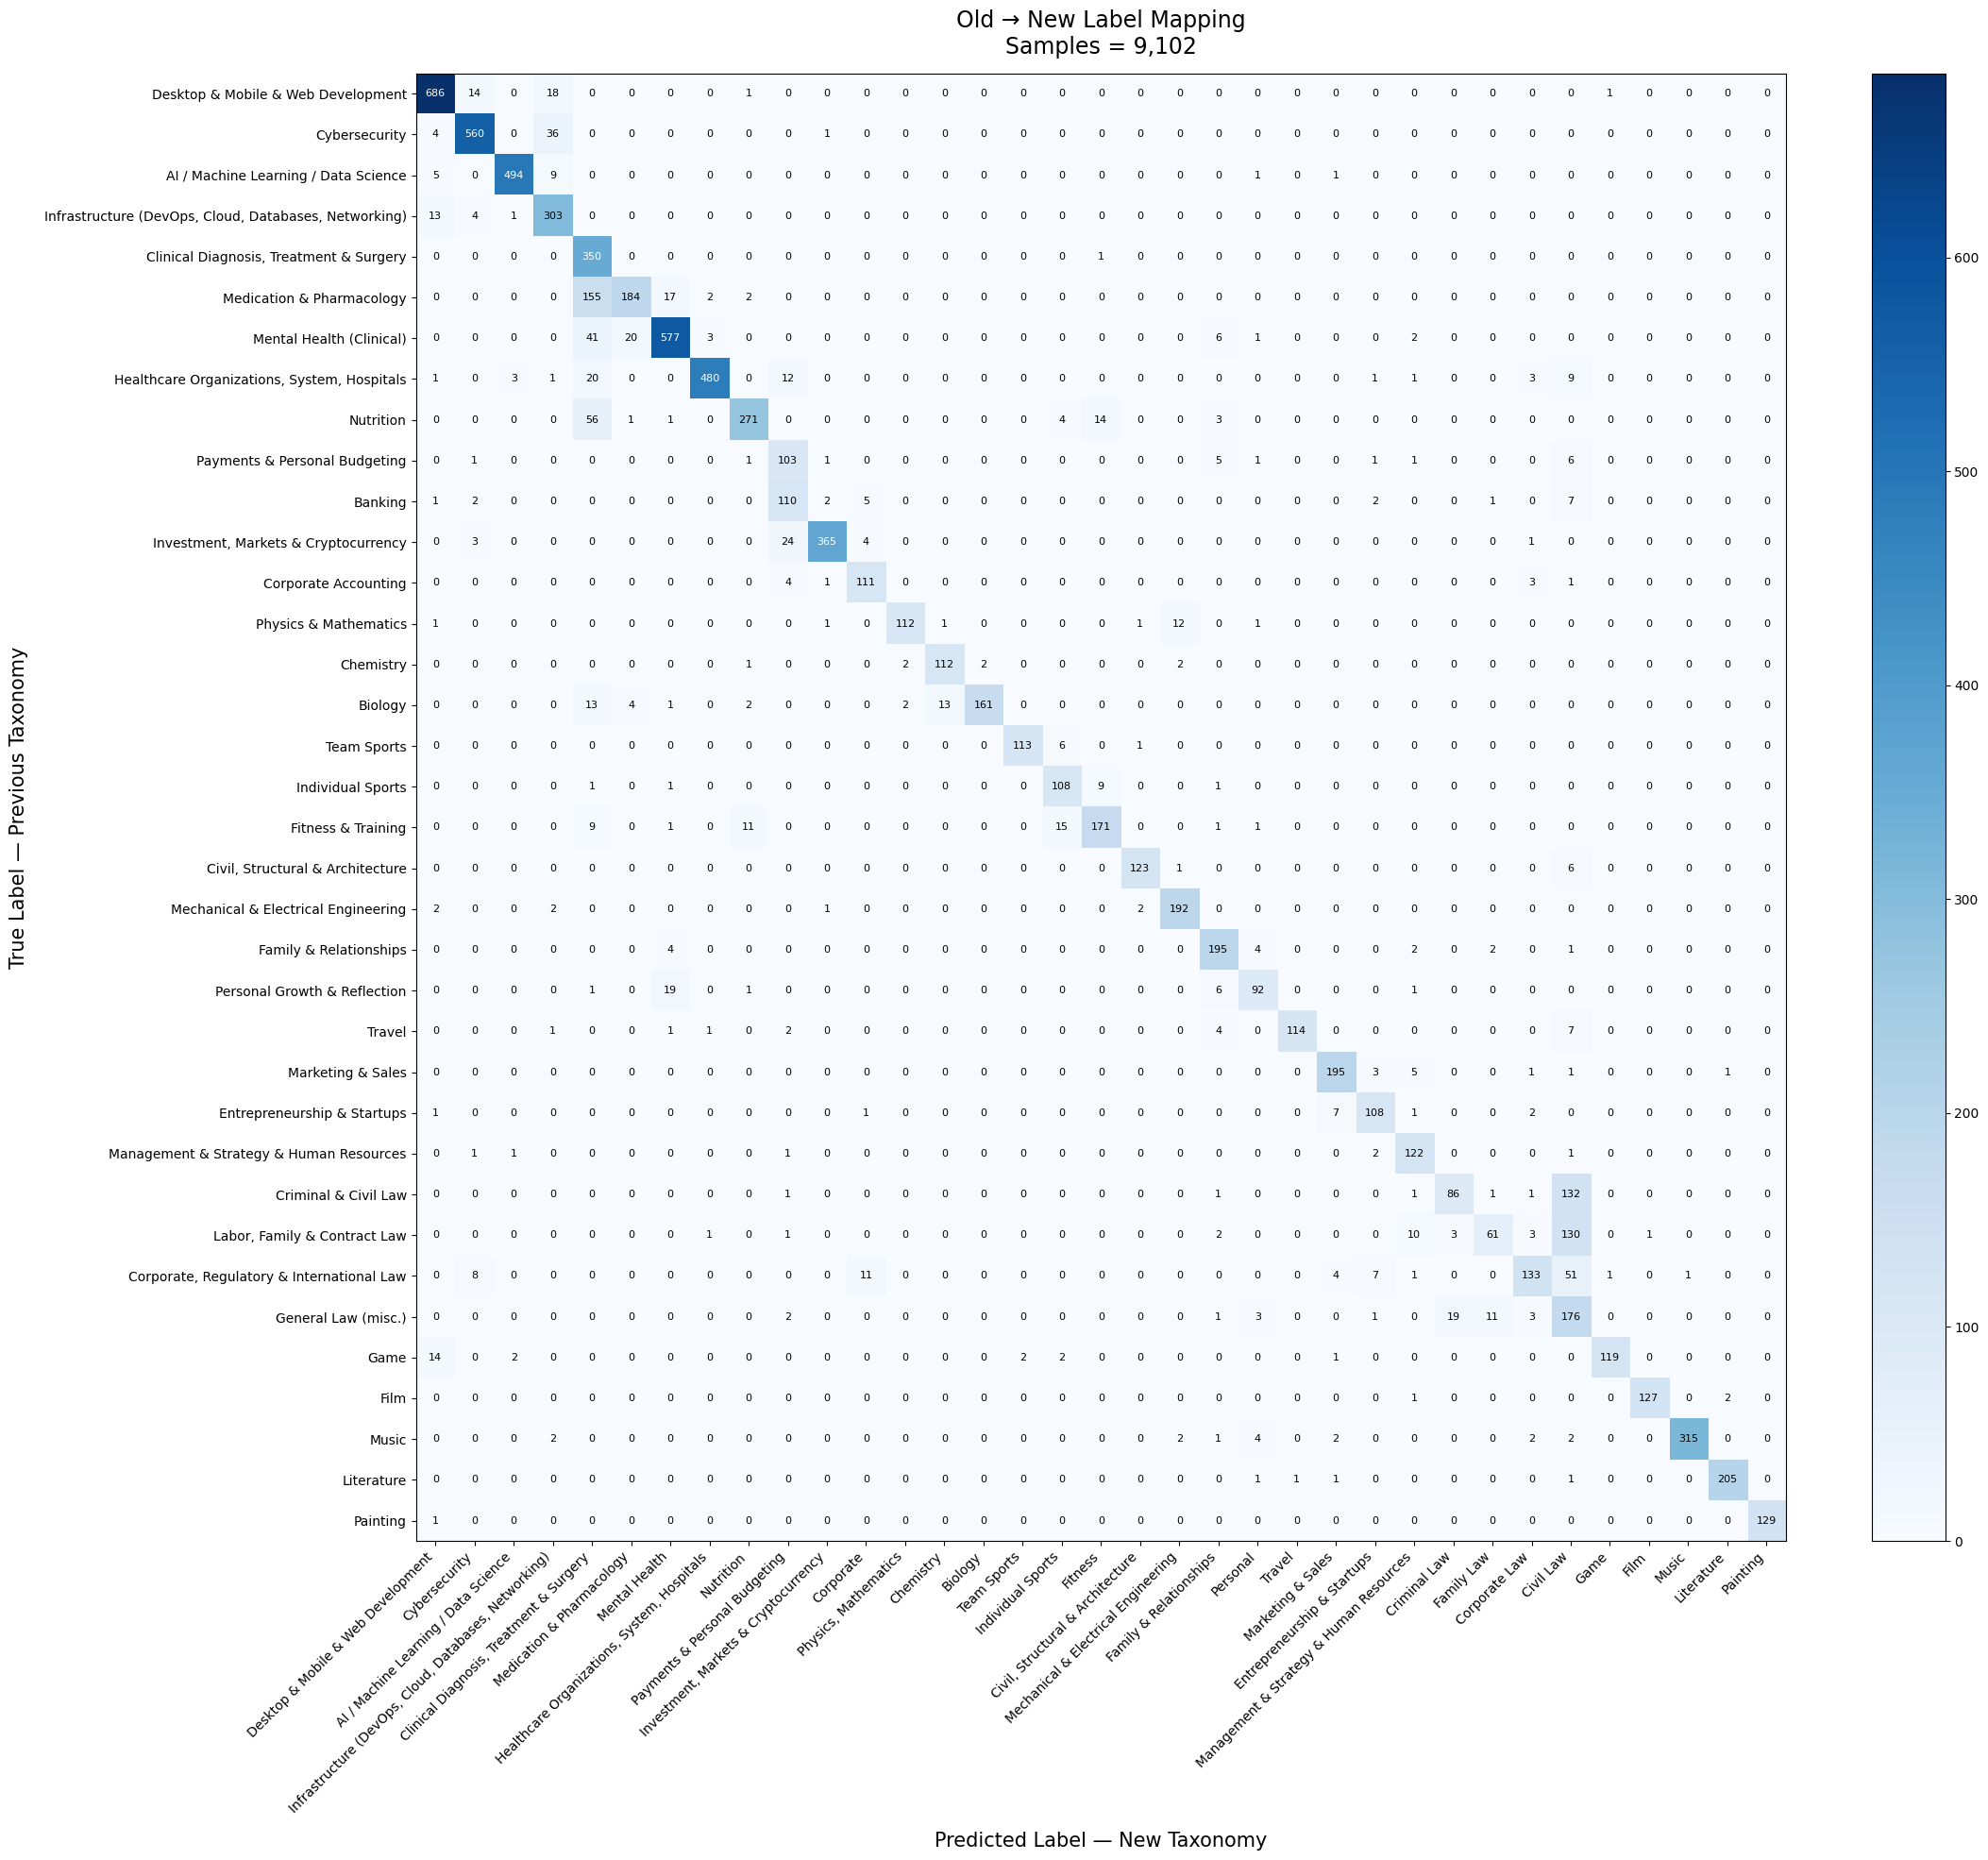


Saved: llm_classification_results/confusion_matrix_old_to_new_labels.png


In [ ]:
# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    # ========================================================
    # 1. LOAD FROM HUGGING FACE
    # ========================================================

    df = load_dataset_from_hf()

    # ========================================================
    # 2. REMOVE EXCLUDED GROUPS
    #    THEN SHUFFLE ONCE
    # ========================================================

    shuffled_df = get_shuffled_dataset(
        df
    )

    # shuffled_df = get_non_shuffled_dataset (
    #     df
    # )

    # ========================================================
    # 3. CLASSIFY SELECTED INDEX RANGE
    # ========================================================

    run_classification(
        shuffled_df,
        START_INDEX,
        END_INDEX,
    )

    # ========================================================
    # 4. PLOT ALL AVAILABLE GENERATION-GROUP CMs
    # ========================================================

    plot_confusion_matrix_3()

## <a name="evaluation-and-visualization"></a>6. Evaluation and Visualization

## misclassification-percent

### <a name="misclassification-analysis"></a>Misclassification Analysis

This section calculates and displays the percentage of misclassified samples for each true label, providing insights into the model's performance on different categories.

In [ ]:
# old_labels = [

#     "Desktop & Mobile & Web Development",

#     "Cybersecurity",

#     "AI / Machine Learning / Data Science",

#     "Infrastructure (DevOps, Cloud, Databases, Networking)",

#     "Clinical Diagnosis, Treatment & Surgery",

#     "Medication & Pharmacology",

#     "Mental Health (Clinical)",

#     "Healthcare Organizations, System, Hospitals",

#     "Nutrition",

#     "Payments & Personal Budgeting",

#     "Banking",

#     "Investment, Markets & Cryptocurrency",

#     "Corporate Accounting",

#     "Physics & Mathematics",

#     "Chemistry",

#     "Biology",

#     "Team Sports",

#     "Individual Sports",

#     "Fitness & Training",

#     "Civil, Structural & Architecture",

#     "Mechanical & Electrical Engineering",

#     "Family & Relationships",

#     "Personal Growth & Reflection",

#     "Travel",

#     "Marketing & Sales",

#     "Entrepreneurship & Startups",

#     "Management & Strategy & Human Resources",

#     "Criminal & Civil Law",

#     "Labor, Family & Contract Law",

#     "Corporate, Regulatory & International Law",

#     "General Law (misc.)",

#     "Game",

#     "Film",

#     "Music",

#     "Literature",

#     "Painting",
# ]

In [ ]:
# labels = [
#     "Desktop & Mobile & Web Development",
#     "Cybersecurity",
#     "AI / Machine Learning / Data Science",
#     "Infrastructure (DevOps, Cloud, Databases, Networking)",
#     "Clinical Diagnosis, Treatment & Surgery",
#     "Medication & Pharmacology",
#     "Mental Health",
#     "Healthcare Organizations, System, Hospitals",
#     "Nutrition",
#     "Payments & Personal Budgeting",
#     "Investment, Markets & Cryptocurrency",
#     "Corporate",
#     "Physics & Mathematics",
#     "Chemistry",
#     "Biology",
#     "Team Sports",
#     "Individual Sports",
#     "Fitness",
#     "Civil, Structural & Architecture",
#     "Mechanical & Electrical Engineering",
#     "Family & Relationships",
#     "Personal",
#     "Travel",
#     "Marketing & Sales",
#     "Entrepreneurship & Startups",
#     "Management & Strategy & Human Resources",
#     "Criminal Law",
#     "Family Law",
#     "Corporate Law",
#     "Civil Law" ,
#     "Game",
#     "Film",
#     "Music",
#     "Literature",
#     "Painting",
# ]

In [ ]:
import json
import pandas as pd

# Load JSON
with open("/content/classification_results_law&medical.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Whether each sample was misclassified
df["misclassified"] = df["label"] != df["llm_prediction"]

# Calculate percentage of misclassified samples per true label
result = (
    df.groupby("label")["misclassified"]
    .mean()
    .mul(100)
    .reset_index(name="Misclassification Percentage")
)

# Force your desired label order
result["label"] = pd.Categorical(
    result["label"],
    categories=labels,
    ordered=True
)

# Sort according to label_order
result = result.sort_values("label").reset_index(drop=True)

result

FileNotFoundError: [Errno 2] No such file or directory: '/content/classification_results_law&medical.json'

In [ ]:
import json

# Path to your JSON file
json_path = "/content/llm_classification_results/classification_results_excluded_a7fd790721.json"

# Generation group you want to keep
target_group = "second_label_desc_Law_parent"

# Load JSON
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Select only samples with the target generation_group
filtered_data = [
    item for item in data
    if item.get("generation_group") == target_group
]

print(f"Total samples: {len(data)}")
print(f"Filtered samples: {len(filtered_data)}")

# Optional: save the filtered samples
output_path = "filtered.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(filtered_data, f, ensure_ascii=False, indent=2)

print(f"Saved to: {output_path}")

Total samples: 1225
Filtered samples: 426
Saved to: filtered.json


### Helper function , json to cm

In [ ]:
old_labels = labels

In [ ]:
# ============================================================
# PLOT OLD LABEL → NEW LABEL MATRIX
# ============================================================
import numpy as np

def plot_confusion_matrix_4(address):

    # Load JSON
    with open(address, "r", encoding="utf-8") as f:
        results = json.load(f)

    if not results:
        print("No classification results found.")
        return

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Only valid predictions
    # --------------------------------------------------------

    valid_df = results_df[
        results_df["llm_prediction"].isin(labels)
    ].copy()

    invalid_count = len(results_df) - len(valid_df)

    print("\n" + "=" * 70)
    print("LABEL MIGRATION EVALUATION")
    print("=" * 70)

    print(f"Total saved predictions: {len(results_df):,}")
    print(f"Valid predictions: {len(valid_df):,}")
    print(f"Invalid predictions: {invalid_count:,}")

    if len(valid_df) == 0:
        print("\nNo valid predictions to evaluate.")
        return

    # --------------------------------------------------------
    # True / predicted labels
    # --------------------------------------------------------

    y_true = valid_df["label"]
    y_pred = valid_df["llm_prediction"]

    # --------------------------------------------------------
    # Build OLD → NEW matrix
    #
    # Rows    = old_labels
    # Columns = labels
    # --------------------------------------------------------

    cm_df = pd.crosstab(
        pd.Categorical(
            y_true,
            categories=old_labels,
            ordered=True,
        ),
        pd.Categorical(
            y_pred,
            categories=labels,
            ordered=True,
        ),
        dropna=False,
    )

    # Make absolutely sure the ordering is correct
    cm_df = cm_df.reindex(
        index=old_labels,
        columns=labels,
        fill_value=0,
    )

    cm = cm_df.to_numpy()
    # ============================================================
    # PERCENTAGE MATRIX
    # Each row sums to 100%
    # ============================================================

    row_totals = cm.sum(axis=1, keepdims=True)

    cm_percent = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0,
    ) * 100


    # ============================================================
    # PLOT
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(
            max(16, len(labels) * 0.65),
            max(12, len(old_labels) * 0.55),
        )
    )

    im = ax.imshow(
        cm_percent,
        interpolation="nearest",
        cmap="Blues",
        aspect="auto",
    )

    # ------------------------------------------------------------
    # Colorbar
    # ------------------------------------------------------------

    cbar = fig.colorbar(im, ax=ax)

    cbar.set_label(
        "Percentage (%)",
        fontsize=12,
    )


    # ------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
        fontsize=10,
    )

    ax.set_yticks(range(len(old_labels)))
    ax.set_yticklabels(
        old_labels,
        fontsize=10,
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=15,
        labelpad=12,
    )

    ax.set_ylabel(
        "True Label ",
        fontsize=15,
        labelpad=12,
    )

    ax.set_title(
        f"Row-normalized percentages | "
        f"Samples = {len(valid_df):,}",
        fontsize=17,
        pad=15,
    )


    # ============================================================
    # CELL BORDERS
    # ============================================================

    # Draw borders around every cell
    ax.set_xticks(
        np.arange(-0.5, len(labels), 1),
        minor=True,
    )

    ax.set_yticks(
        np.arange(-0.5, len(old_labels), 1),
        minor=True,
    )

    ax.grid(
        which="minor",
        color="gray",
        linestyle="-",
        linewidth=0.5,
    )

    # Don't show minor tick marks
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )


    # ============================================================
    # ADD PERCENTAGES
    # ============================================================

    threshold = cm_percent.max() / 2

    for i in range(len(old_labels)):
        for j in range(len(labels)):

            value = cm_percent[i, j]

            # Don't write anything for zero cells
            if value == 0:
                continue

            ax.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > threshold else "black",
            )


    # ============================================================
    # LIMITS
    # ============================================================

    ax.set_xlim(
        -0.5,
        len(labels) - 0.5,
    )

    ax.set_ylim(
        len(old_labels) - 0.5,
        -0.5,
    )

    plt.tight_layout()


    # ============================================================
    # SAVE
    # ============================================================

    # filename = os.path.join(
    #     RESULTS_DIR,
    #     "confusion_matrix_old_to_new_percentages.png",
    # )

    # plt.savefig(
    #     filename,
    #     dpi=250,
    #     bbox_inches="tight",
    # )

    plt.show()

    # print(f"\nSaved: {filename}")

### <a name="generic-confusion-matrix-plotter"></a>Generic Confusion Matrix Plotter

This function allows plotting a confusion matrix from a specified JSON results file, providing flexibility for analyzing different subsets of classification results.


LABEL MIGRATION EVALUATION
Total saved predictions: 7,466
Valid predictions: 7,466
Invalid predictions: 0


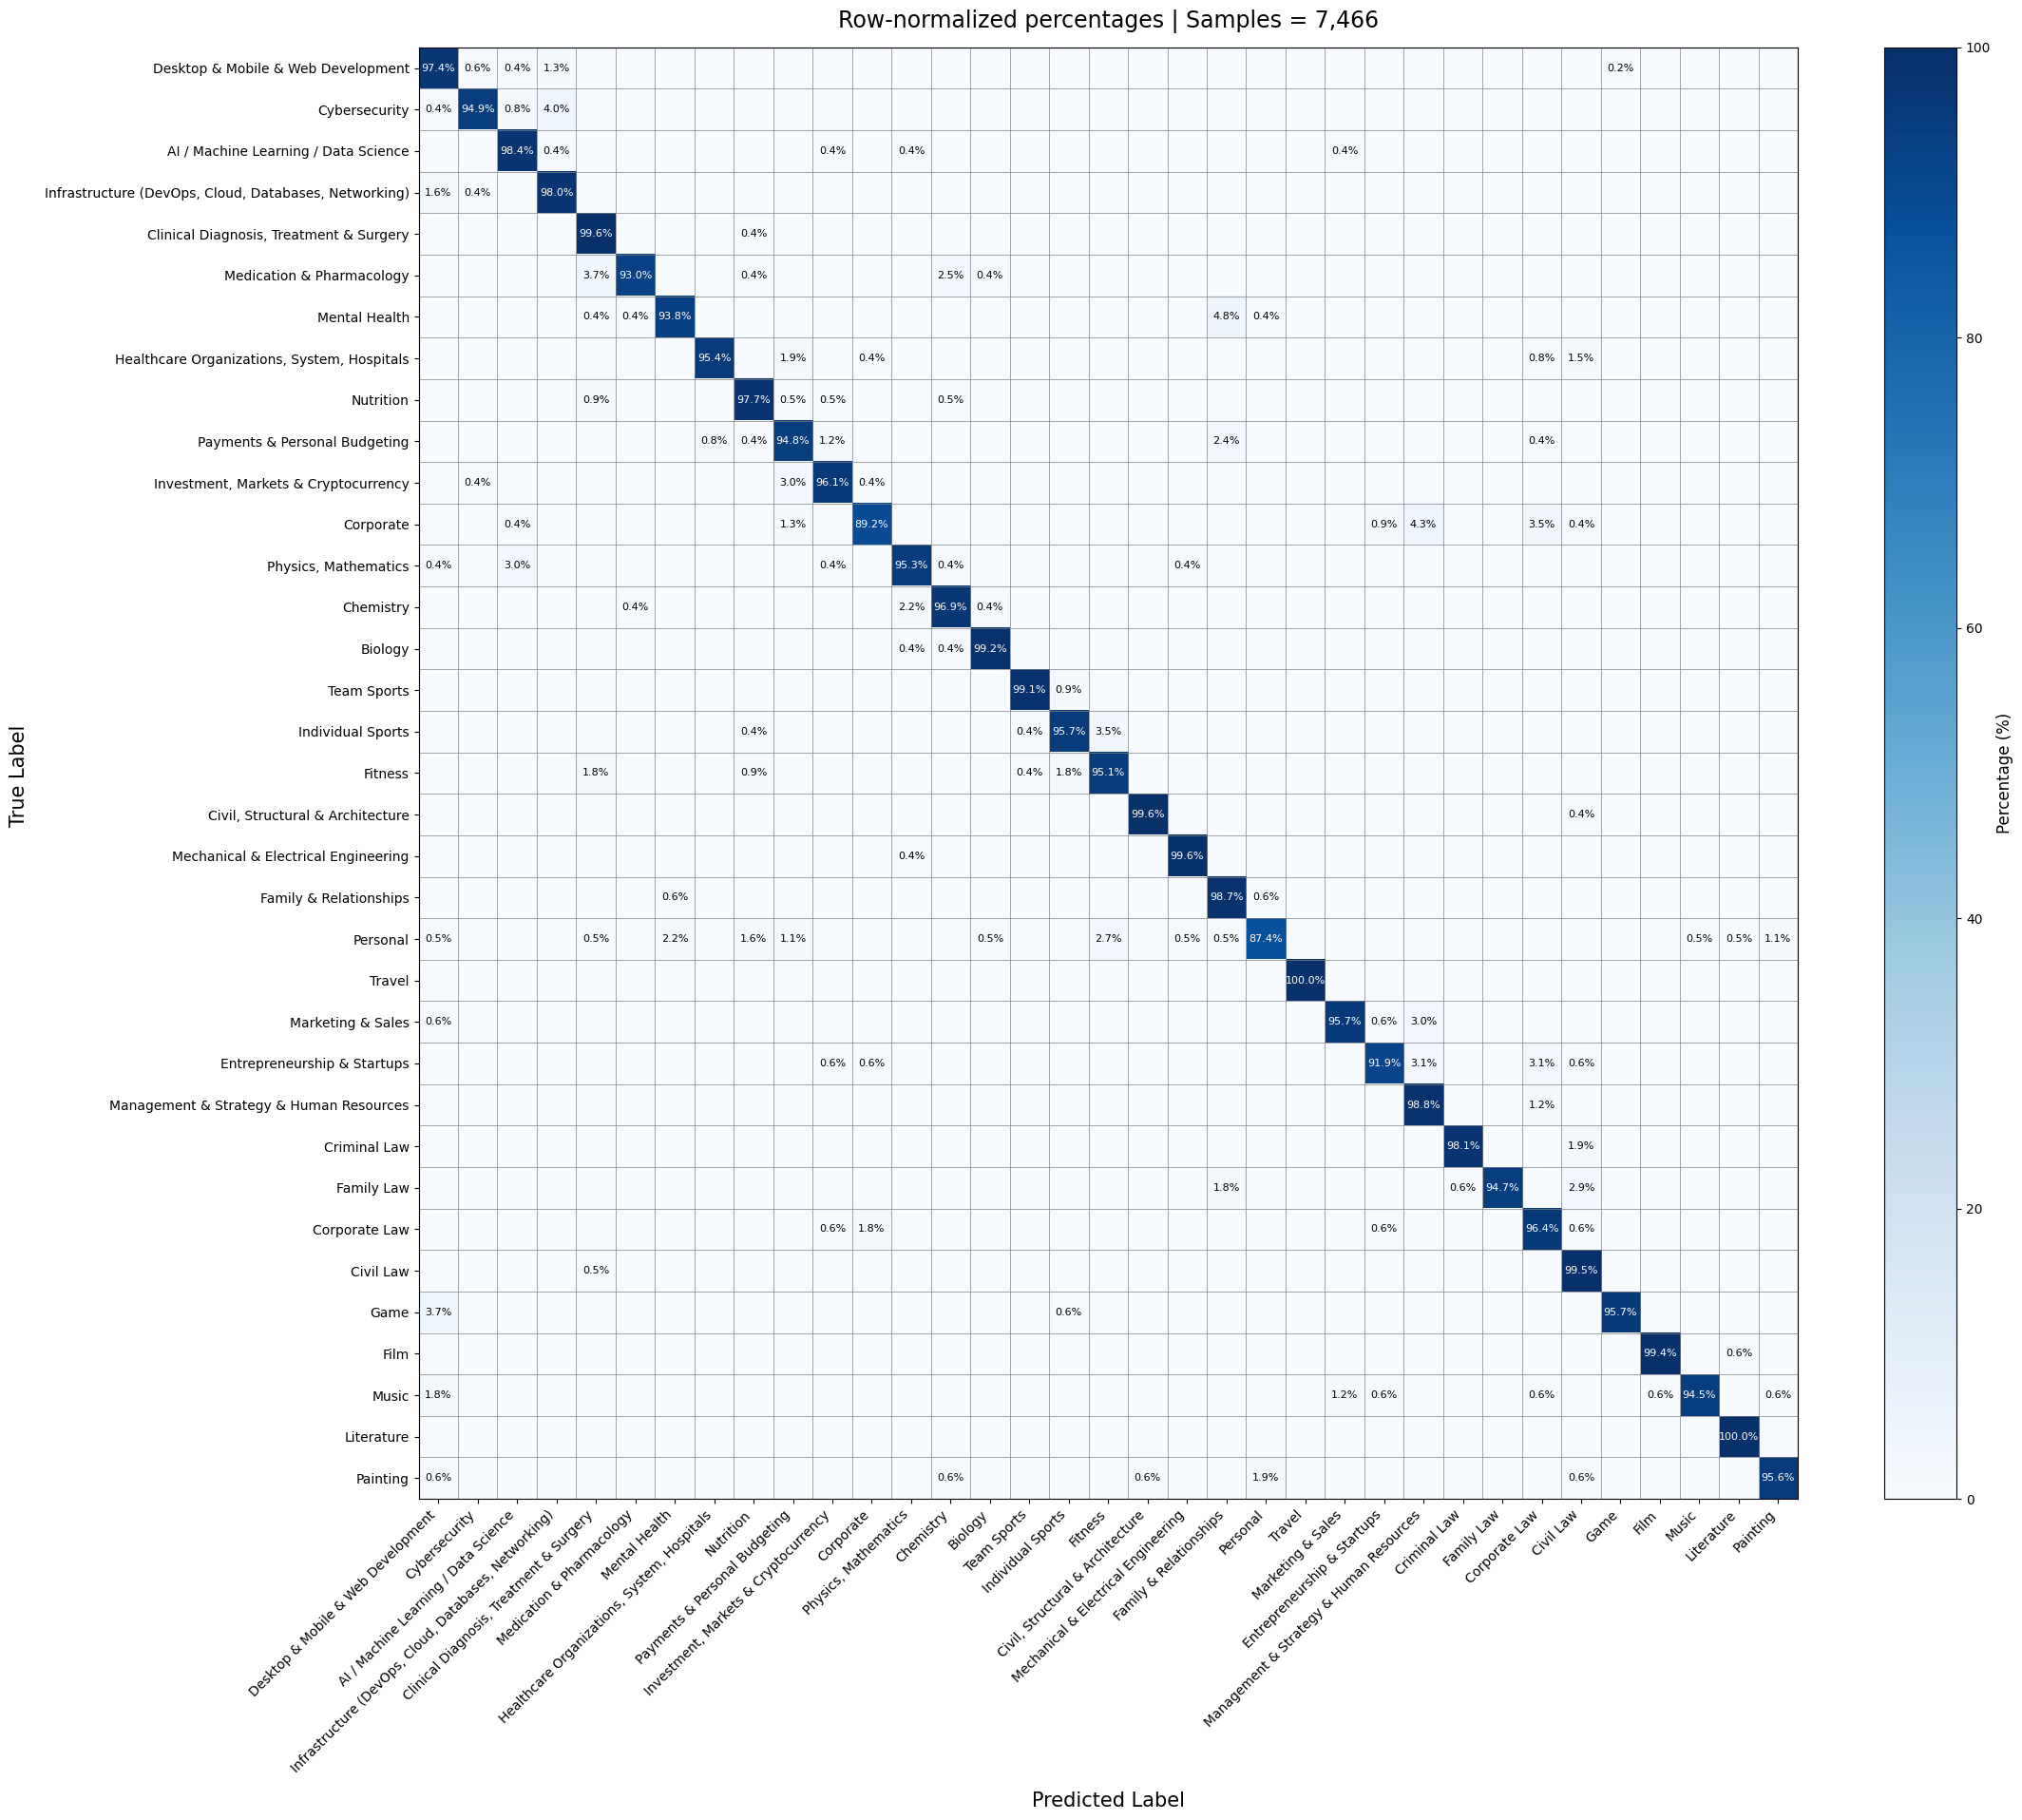

In [ ]:
plot_confusion_matrix_4("/content/classification_results_excluded_dfc2814242 (1) (copy).json")